# Advanced Analysis of 20260506_091738 E2 (keep)

This notebook provides an in-depth analysis of the model evaluation results, including parameter correlations, impact of 'Thinking' mechanisms, and detailed query-level performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual style for a premium look
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
custom_palette = sns.color_palette("husl", 16)

In [2]:
summary_dir = "../outputs/summary/archive_04-2026_to_06-2026/20260506_091738 E2 (keep)"
model_comp_file = os.path.join(summary_dir, "model_summary_models_comparison_20260506_091738.csv")
model_all_file = os.path.join(summary_dir, "model_summary_all_20260506_091738.csv")

df_comp = pd.read_csv(model_comp_file)
df_all = pd.read_csv(model_all_file)

# Preprocessing
df_comp['Display Name'] = df_comp.apply(lambda row: f"{row['Name']} (T={row['Thinking']})", axis=1)
df_all['Display Name'] = df_all.apply(lambda row: f"{row['Name']} (T={row['Thinking']})", axis=1)

# Clean Parameters to numeric (approximate for '35B-A3B' -> 35)
def extract_params(p_str):
    if pd.isna(p_str): return np.nan
    # Take the first sequence of digits
    import re
    match = re.search(r'(\d+\.?\d*)', str(p_str))
    return float(match.group(1)) if match else np.nan

df_comp['Params_Num'] = df_comp['Parameters'].apply(extract_params)
df_all['Params_Num'] = df_all['Parameters'].apply(extract_params)

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/summary/archive_04-2026_to_06-2026/20260506_091738 E2 (keep)\\model_summary_models_comparison_20260506_091738.csv'

## 1. High-Level Metrics Comparison
A 2x2 grid comparing the most important metrics across all models.

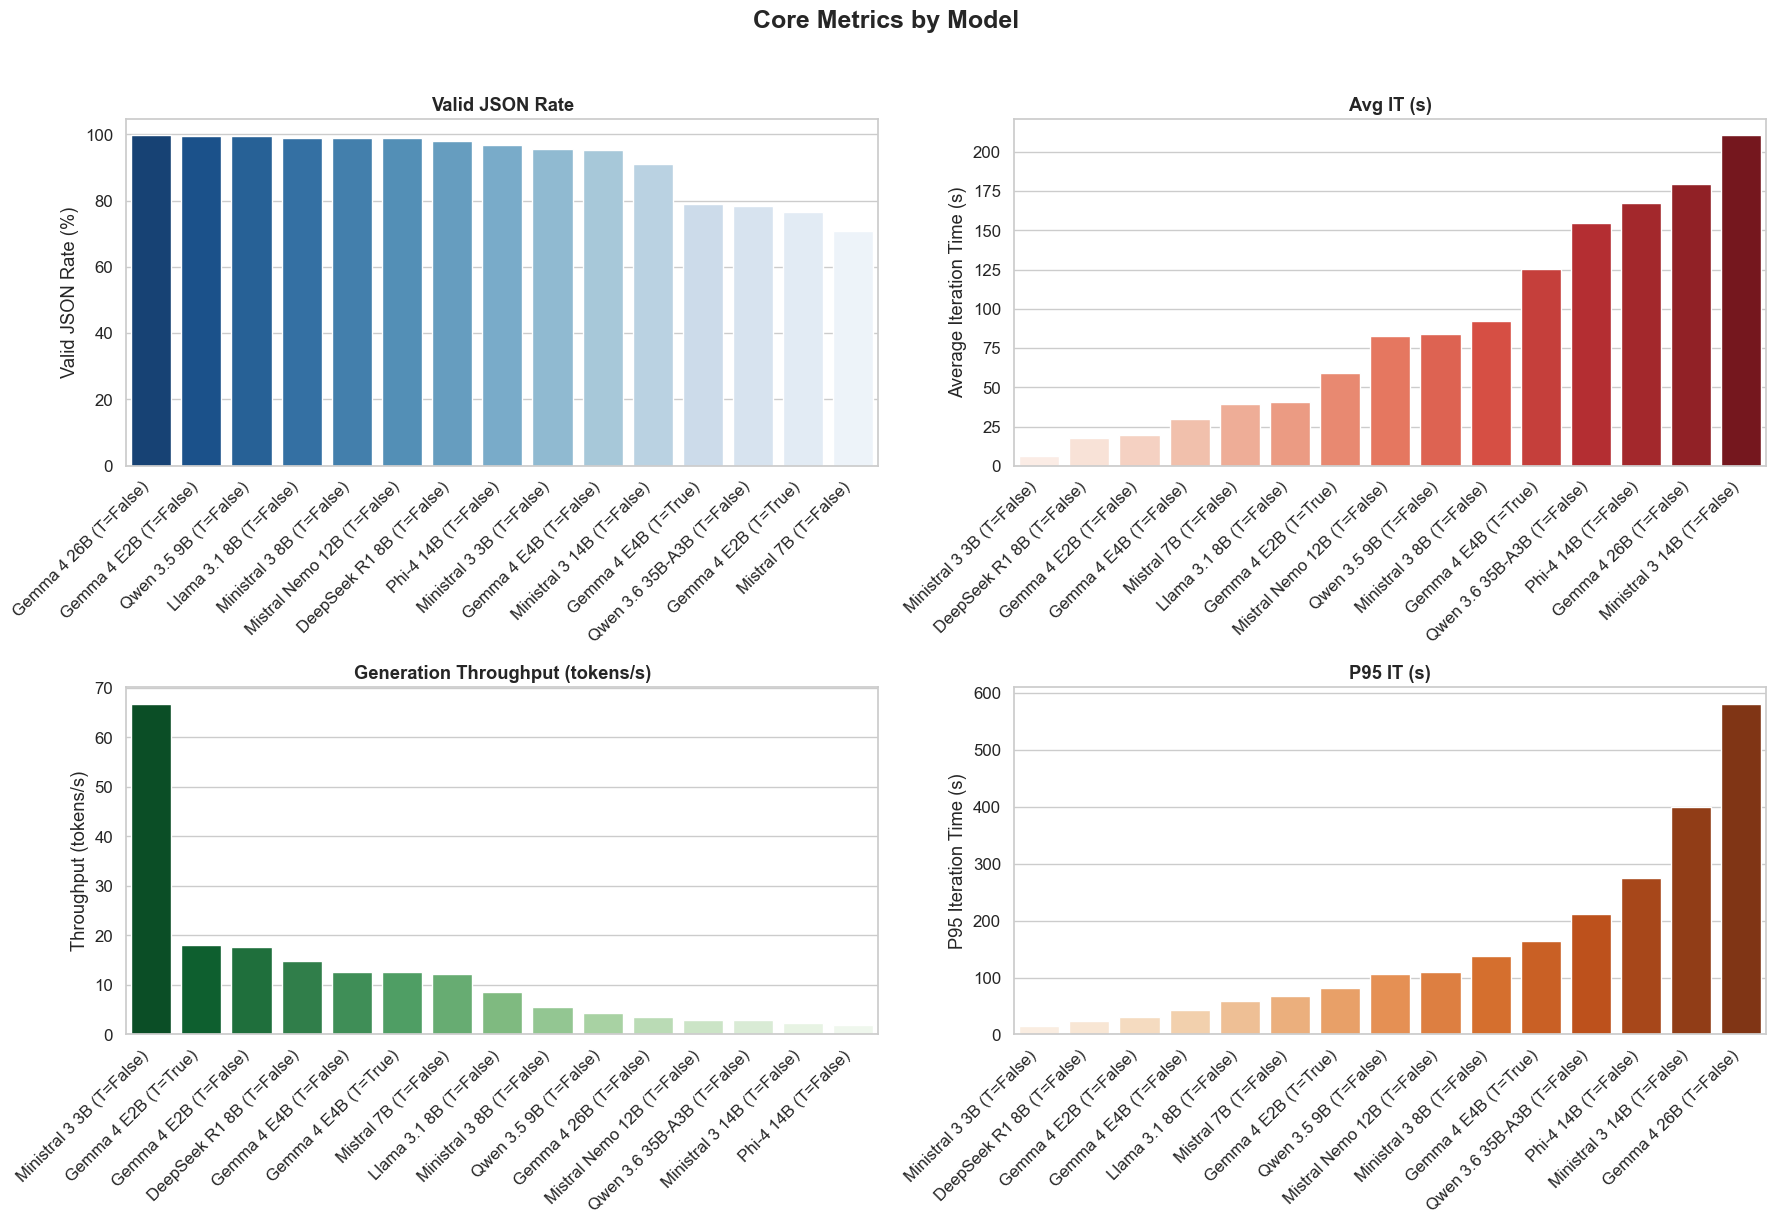

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Core Metrics by Model', fontsize=18, fontweight='bold', y=1.02)

metrics = [('Valid JSON Rate', 'Valid JSON Rate (%)', axes[0,0], 'Blues_r'),
           ('Avg IT (s)', 'Average Iteration Time (s)', axes[0,1], 'Reds'),
           ('Generation Throughput (tokens/s)', 'Throughput (tokens/s)', axes[1,0], 'Greens_r'),
           ('P95 IT (s)', 'P95 Iteration Time (s)', axes[1,1], 'Oranges')]

for col, ylabel, ax, cmap in metrics:
    order = df_comp.sort_values(col, ascending=(col != 'Valid JSON Rate' and col != 'Generation Throughput (tokens/s)'))['Display Name']
    sns.barplot(data=df_comp, x='Display Name', y=col, ax=ax, order=order, palette=cmap)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 2. Correlation Analysis
How do parameters like model size (Parameters), Iteration Time, and Throughput correlate with Valid JSON Rate?

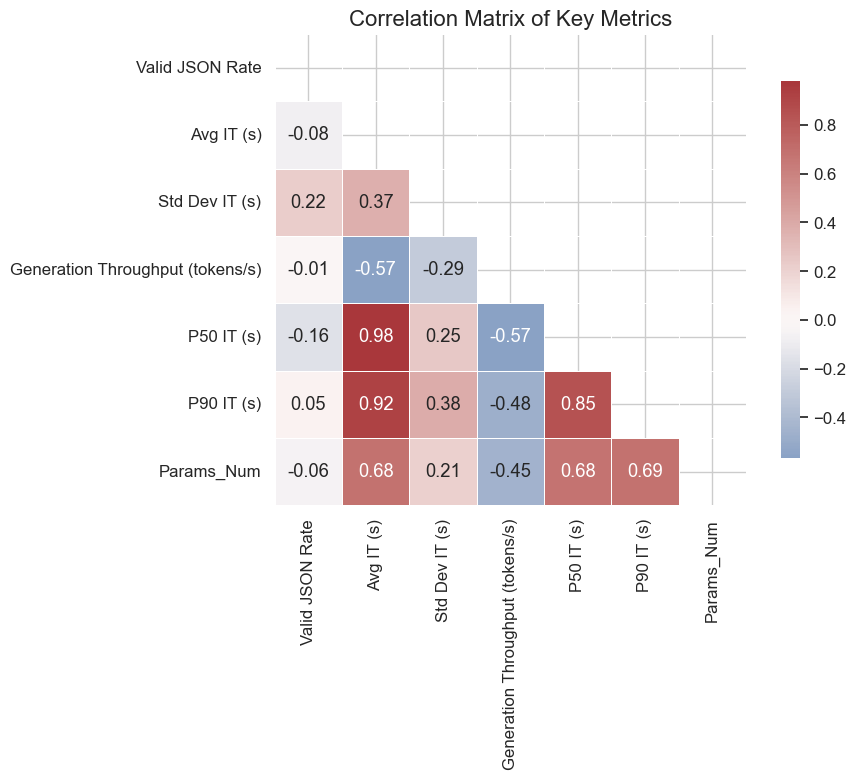

In [ ]:
corr_cols = ['Valid JSON Rate', 'Avg IT (s)', 'Std Dev IT (s)', 'Generation Throughput (tokens/s)', 'P50 IT (s)', 'P90 IT (s)', 'Params_Num']
corr_matrix = df_comp[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='vlag', fmt=".2f", center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Key Metrics', fontsize=16)
plt.tight_layout()
plt.show()

## 3. The Impact of 'Thinking'
Some models were evaluated with and without the `Thinking` parameter. Let's see how it affects performance.

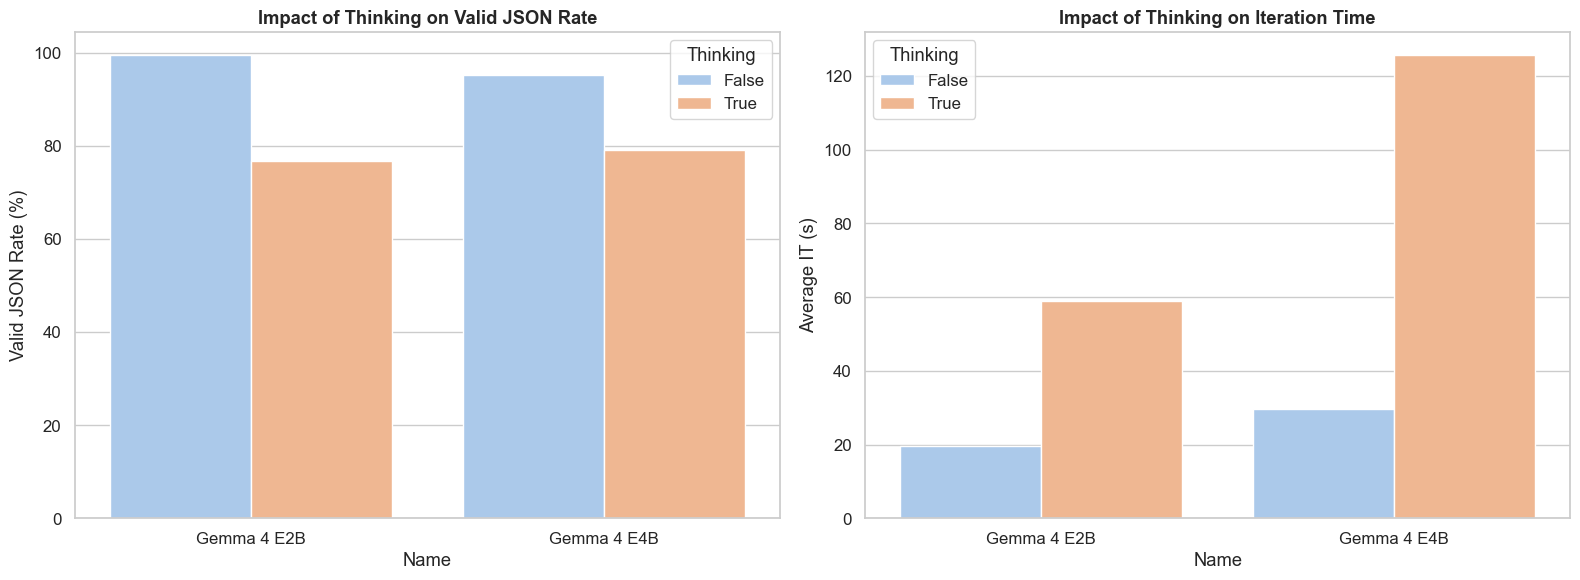

In [ ]:
thinking_models = df_comp[df_comp['Name'].duplicated(keep=False)].sort_values('Name')
if not thinking_models.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=thinking_models, x='Name', y='Valid JSON Rate', hue='Thinking', ax=axes[0], palette='pastel')
    axes[0].set_title('Impact of Thinking on Valid JSON Rate', fontweight='bold')
    axes[0].set_ylabel('Valid JSON Rate (%)')
    
    sns.barplot(data=thinking_models, x='Name', y='Avg IT (s)', hue='Thinking', ax=axes[1], palette='pastel')
    axes[1].set_title('Impact of Thinking on Iteration Time', fontweight='bold')
    axes[1].set_ylabel('Average IT (s)')
    
    plt.tight_layout()
    plt.show()
else:
    print("No models with varying 'Thinking' parameter found.")

## 4. Parameter Size vs. Performance
Does a larger model guarantee better JSON validity? How does it affect throughput?

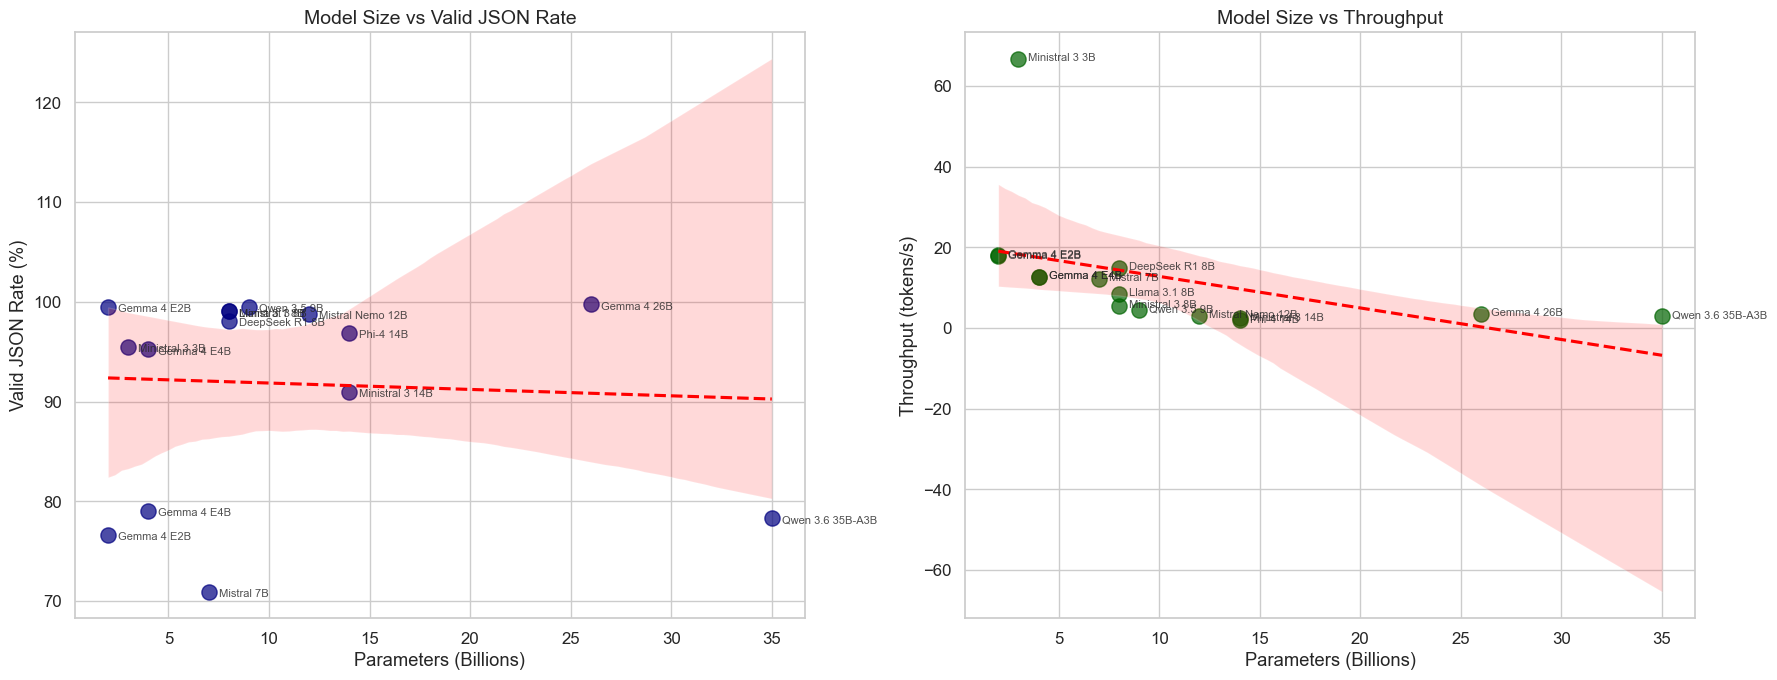

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.regplot(data=df_comp, x='Params_Num', y='Valid JSON Rate', ax=axes[0], scatter_kws={'s': 120, 'alpha': 0.7, 'color': 'navy'}, line_kws={'color': 'red', 'linestyle': '--'})
axes[0].set_title('Model Size vs Valid JSON Rate', fontsize=14)
axes[0].set_xlabel('Parameters (Billions)')
axes[0].set_ylabel('Valid JSON Rate (%)')

sns.regplot(data=df_comp, x='Params_Num', y='Generation Throughput (tokens/s)', ax=axes[1], scatter_kws={'s': 120, 'alpha': 0.7, 'color': 'darkgreen'}, line_kws={'color': 'red', 'linestyle': '--'})
axes[1].set_title('Model Size vs Throughput', fontsize=14)
axes[1].set_xlabel('Parameters (Billions)')
axes[1].set_ylabel('Throughput (tokens/s)')

for i, row in df_comp.iterrows():
    axes[0].annotate(row['Name'], (row['Params_Num']+0.5, row['Valid JSON Rate']-0.5), fontsize=8, alpha=0.8)
    axes[1].annotate(row['Name'], (row['Params_Num']+0.5, row['Generation Throughput (tokens/s)']-0.5), fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

## 5. Granular Query Analysis (Violin Plots)
Understanding the distribution of iteration times across queries. Violin plots show the full density of the data.

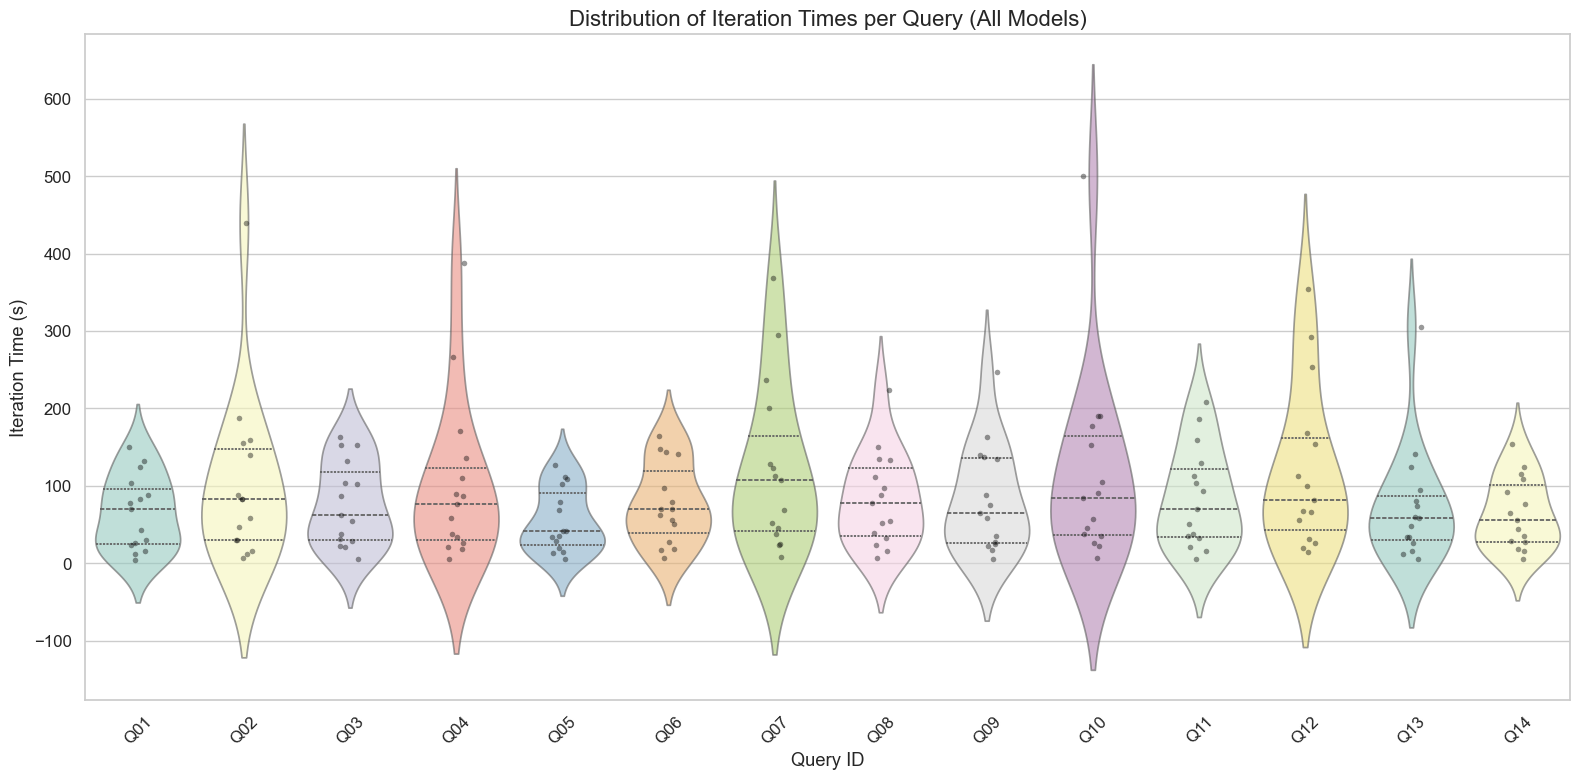

In [ ]:
plt.figure(figsize=(16, 8))
sns.violinplot(data=df_all.sort_values('Query ID'), x='Query ID', y='Avg IT (s)', inner='quartile', palette='Set3', alpha=0.6)
sns.stripplot(data=df_all.sort_values('Query ID'), x='Query ID', y='Avg IT (s)', color='black', alpha=0.4, size=4, jitter=True)
plt.xticks(rotation=45)
plt.title('Distribution of Iteration Times per Query (All Models)', fontsize=16)
plt.ylabel('Iteration Time (s)')
plt.tight_layout()
plt.show()

## 6. Model Consistency Heatmaps
Which models are consistently good across all queries? Which queries are universally hard?

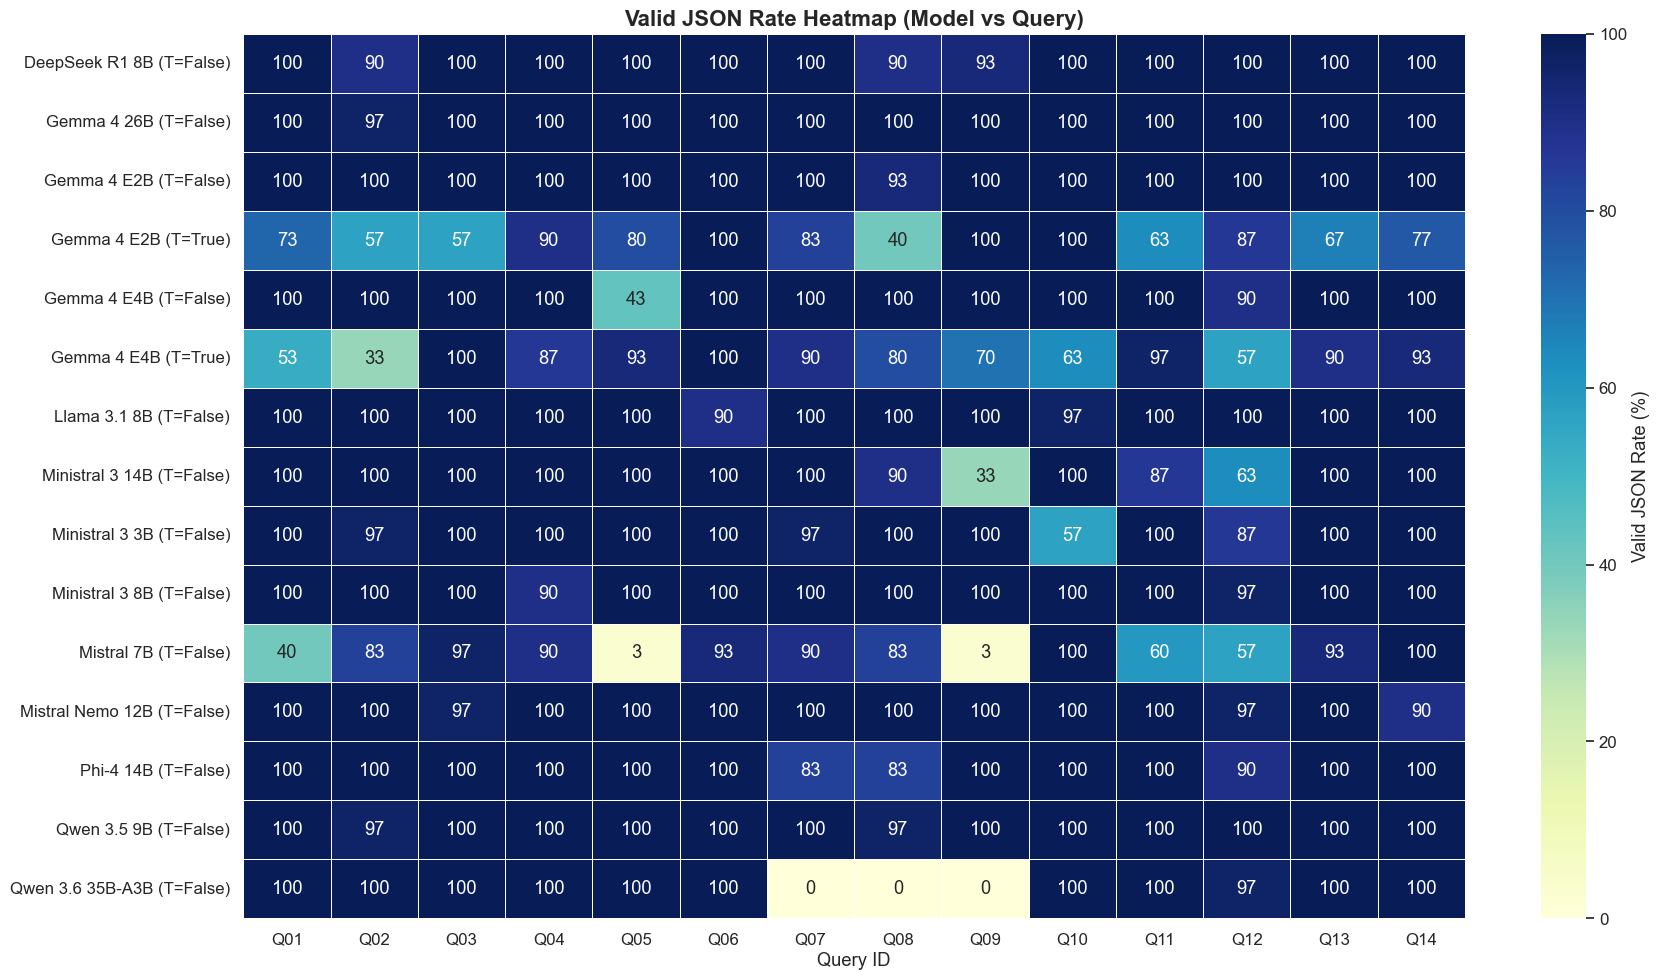

In [ ]:
pivot_json = df_all.pivot_table(index='Display Name', columns='Query ID', values='Valid JSON Rate')
plt.figure(figsize=(18, 10))
sns.heatmap(pivot_json, annot=True, cmap='YlGnBu', vmin=0, vmax=100, fmt=".0f", linewidths=.5, cbar_kws={'label': 'Valid JSON Rate (%)'})
plt.title('Valid JSON Rate Heatmap (Model vs Query)', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 7. Pareto Frontier: Speed vs Quality
Finding the optimal models that balance High JSON Validity with Low Iteration Time.

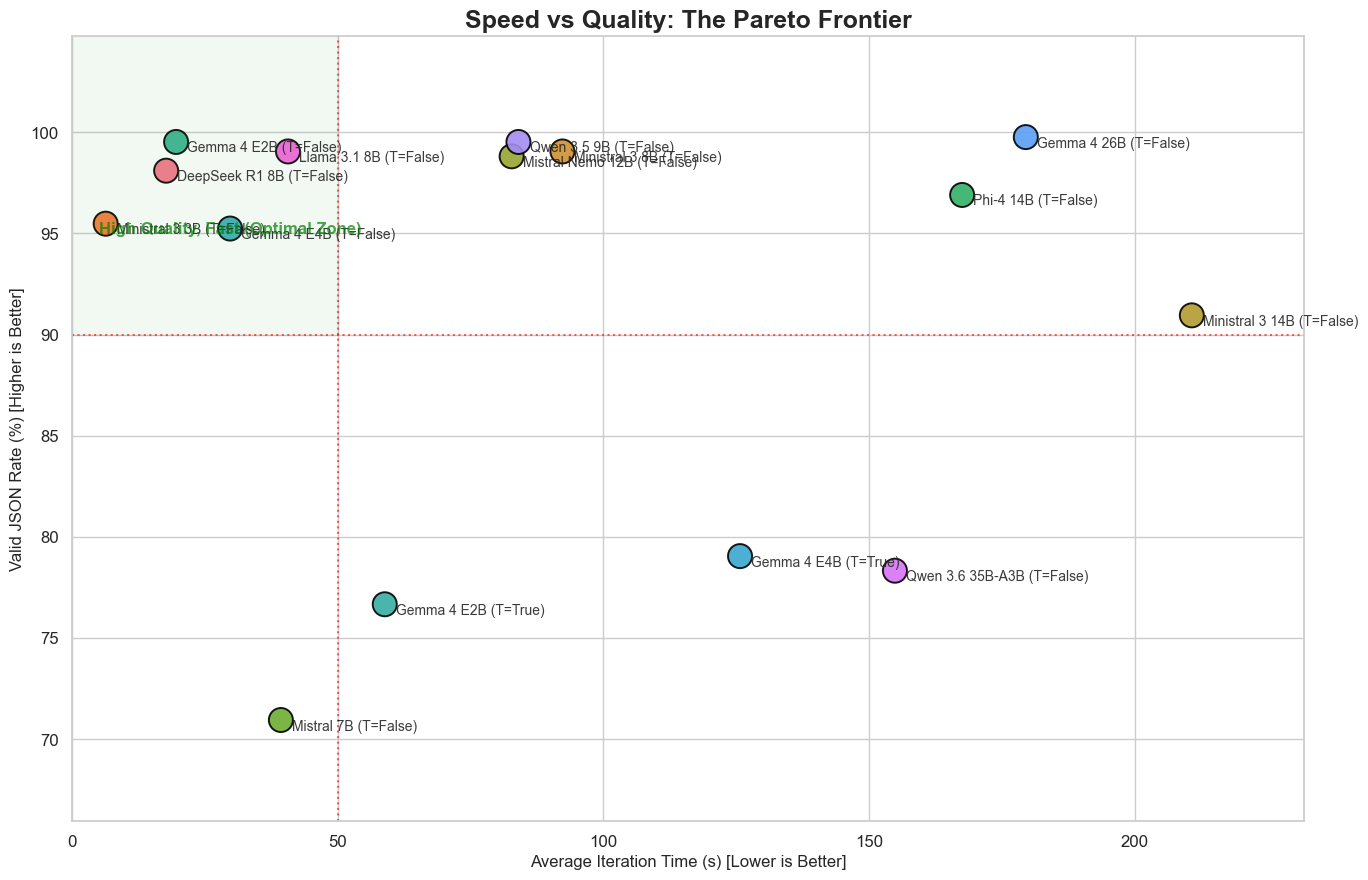

In [ ]:
plt.figure(figsize=(14, 9))
scatter = sns.scatterplot(data=df_comp, x='Avg IT (s)', y='Valid JSON Rate', hue='Display Name', 
                          s=300, palette=custom_palette, legend=False, alpha=0.9, edgecolor='black')

for i, row in df_comp.iterrows():
    plt.annotate(row['Display Name'], 
                 (row['Avg IT (s)'] + max(1, df_comp['Avg IT (s)'].max()*0.01), 
                  row['Valid JSON Rate'] - max(0.5, df_comp['Valid JSON Rate'].max()*0.005)),
                 fontsize=10, alpha=0.9)

plt.title('Speed vs Quality: The Pareto Frontier', fontsize=18, fontweight='bold')
plt.xlabel('Average Iteration Time (s) [Lower is Better]', fontsize=12)
plt.ylabel('Valid JSON Rate (%) [Higher is Better]', fontsize=12)

# Highlight the best quadrant (assuming >90% JSON valid and <50s IT is optimal for this dataset)
plt.axhline(90, color='red', linestyle=':', alpha=0.6)
plt.axvline(50, color='red', linestyle=':', alpha=0.6)
plt.fill_betweenx([90, df_comp['Valid JSON Rate'].max()+5], 0, 50, color='green', alpha=0.05)
plt.text(5, 95, 'High Quality, Fast (Optimal Zone)', color='green', fontsize=12, fontweight='bold', alpha=0.7)

plt.xlim(0, df_comp['Avg IT (s)'].max() * 1.1)
plt.ylim(df_comp['Valid JSON Rate'].min() - 5, df_comp['Valid JSON Rate'].max() + 5)
plt.tight_layout()
plt.show()